Download [dataset](https://www.kaggle.com/competitions/classification-of-butterflies)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

seed = 42
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"

learning_rate = 2e-4
batch_size = 64
epochs = 40

device

device(type='cuda')

In [7]:
import os
import sys

try:
    from data_pipeline import build_dataloaders
except ModuleNotFoundError:
    sys.path.insert(0, os.path.abspath("Homework_13_butterfly_classification"))
    from data_pipeline import build_dataloaders

full_train_dataset, train_loader, valid_loader, test_loader, data_meta = build_dataloaders(
    seed=seed,
    batch_size=batch_size,
    device=device,
)
num_classes = data_meta["num_classes"]

print("-" * 100)
print(f"Train length: {data_meta['train_len']}")
print(f"Valid length: {data_meta['valid_len']}")
print(f"Test length: {data_meta['test_len']}")


----------------------------------------------------------------------------------------------------
Train length: 3944
Valid length: 1011
Test length: 250


In [8]:
full_train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

weights = models.ConvNeXt_Small_Weights.DEFAULT
net = models.convnext_small(weights=weights)
in_features = net.classifier[-1].in_features
net.classifier[-1] = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(in_features, num_classes),
)
net = net.to(device)

backbone_params, head_params = [], []
for name, p in net.named_parameters():
    if not p.requires_grad:
        continue
    (head_params if name.startswith("classifier") else backbone_params).append(p)

optimizer = optim.AdamW(
    [
        {"params": backbone_params, "lr": learning_rate * 0.1},
        {"params": head_params, "lr": learning_rate},
    ],
    weight_decay=1e-4,
)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scheduler = lambda opt: optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", patience=3, factor=0.5)

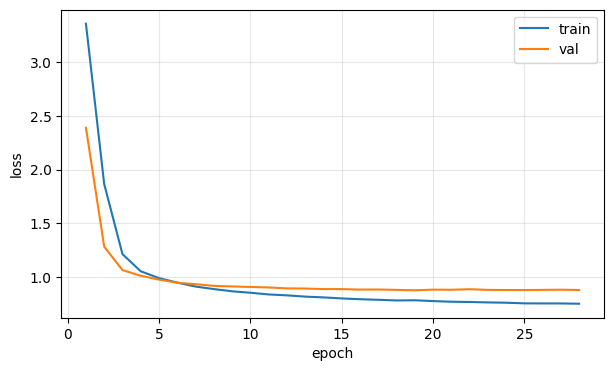

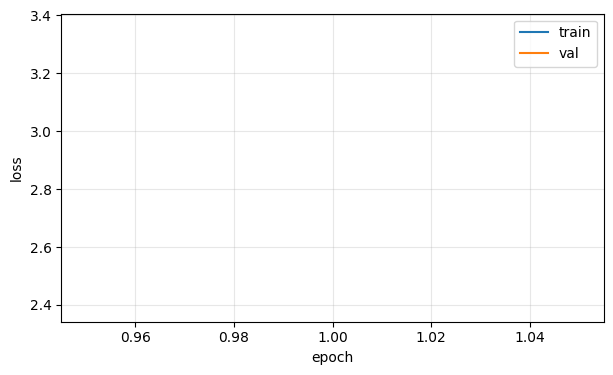

In [10]:
import os
import sys
import importlib

trainer_dir = (
    os.path.abspath("Homework_13_butterfly_classification")
    if os.path.isdir("Homework_13_butterfly_classification")
    else os.path.abspath(".")
)
if trainer_dir not in sys.path:
    sys.path.insert(0, trainer_dir)


from trainer import fit_with_live_plot
trainer, history = fit_with_live_plot(
    net,
    criterion,
    optimizer,
    device,
    train_loader,
    valid_loader,
    epoch_amount=epochs,
    early_stopping=8,
    scheduler=scheduler,
)

In [ ]:
# from trainer import Trainer
# trainer.save_best_model("data/butterfly_net.pt")
# trainer = Trainer.from_checkpoint(net, device, "data/butterfly_net.pt")

In [12]:
from pathlib import Path

pred = trainer.predict(test_loader)
pred = pred.softmax(dim=1).argmax(dim=1).numpy()

test_index = [int(Path(p).stem) for p in data_meta["test_file_names"]]
submission = pd.DataFrame({"index": test_index, "label": pred})
submission.to_csv("data/predictions.csv", index=False)
submission

,index,label
0,0,14
1,1,40
2,2,8
3,3,37
4,4,27
...,...,...
245,245,32
246,246,6
247,247,2
248,248,4
